# Importing Neccessary Packages

In [96]:
import pandas as  pd
import  numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px 
from sklearn.preprocessing import OneHotEncoder , LabelEncoder
from sklearn.feature_selection import  RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

In [43]:
df=pd.read_csv('credit-risk-cleaned.csv')

In [44]:
pd.set_option('display.max_columns', None)

In [45]:
df.head()

,Company name,Turnover.2020,Turnover.2019,Turnover.2018,Turnover.2017,Turnover.2016,Turnover.2015,EBIT.2020,EBIT.2019,EBIT.2018,EBIT.2017,EBIT.2016,EBIT.2015,PLTax.2020,PLTax.2019,PLTax.2018,PLTax.2017,PLTax.2016,PLTax.2015,MScore.2020,MScore.2019,MScore.2018,MScore.2017,MScore.2016,MScore.2015,Region,Country,NACE code,Sector 1,Sector 2,Leverage.2020,Leverage.2019,Leverage.2018,Leverage.2017,Leverage.2016,Leverage.2015,ROE.2020,ROE.2019,ROE.2018,ROE.2017,ROE.2016,ROE.2015,TAsset.2020,TAsset.2019,TAsset.2018,TAsset.2017,TAsset.2016,TAsset.2015
0,LENDLEASE S.R.L.,29458,16716,9612,8097,7941.0,5600.0,-1556.0,-4540.0,623.0,-412.0,885.0,-1479.0,-1402.0,-4674.0,22.0,-360.0,368.0,-1140.0,CC,CC,CCC,C,BB,C,Milano,Italy,4200,Civil engineering,Capital Goods,14.33,9.90,56.77,64.15,21.46,48.07,-43.63,-180.22,8.24,-146.65,60.76,-471.72,49263,28268,15455,15992,13597.0,11659.0
1,PRICEWATERHOUSECOOPERS BUSINESS SERVICES SRL (...,16731,16403,16843,12241,9252.0,9515.0,1838.0,841.0,2738.0,-864.0,-2212.0,-3572.0,1600.0,700.0,2577.0,-900.0,-2187.0,-4591.0,A,BBB,BBB,CC,CCC,CCC,Milano,Italy,7022,Activities of head offices; management consult...,Commercial and professional services,1.86,2.45,2.92,5.65,2.90,1.29,27.60,14.30,61.42,-55.57,-127.29,-87.13,16550,16887,16468,10773,6697.0,8933.0
2,EVISO S.P.A.,48568,43039,34302,25791,19760.0,6941.0,1661.0,1464.0,976.0,495.0,162.0,224.0,1159.0,1047.0,779.0,267.0,63.0,123.0,BBB,BBB,BBB,BB,BB,BB,Cuneo,Italy,3514,"ELECTRICITY, GAS, STEAM AND AIR CONDITIONING S...",Utilities,3.59,3.49,4.44,7.69,12.54,9.39,39.38,48.89,57.52,42.73,20.34,44.62,13500,9620,7371,5432,4170.0,2862.0
3,CASA SERVICE MACHINE,47999,43484,43043,41682,51267.0,52584.0,416.0,255.0,-855.0,-23.0,426.0,969.0,236.0,107.0,-1002.0,-197.0,430.0,602.0,BB,B,CCC,B,BB,BB,Pas-de-Calais,France,4661,"Wholesale trade, except of motor vehicles and ...",Retailing,3.54,3.89,4.15,2.64,3.21,3.18,8.42,5.69,-17.24,0.71,2.89,6.45,24978,25032,25729,21632,25403.0,24941.0
4,PANFERTIL SPA,45948,47336,45626,48222,57074.0,62263.0,44.0,713.0,-672.0,-1091.0,97.0,987.0,3.0,48.0,-599.0,-821.0,-10.0,-1116.0,B,BB,CCC,CCC,B,B,Ravenna,Italy,4675,"Wholesale trade, except of motor vehicles and ...",Retailing,2.17,1.98,2.13,2.15,2.15,2.11,0.03,0.41,-5.17,-6.74,0.03,-8.19,36823,34659,36205,38423,41847.0,41323.0


In [46]:
df.tail()

,Company name,Turnover.2020,Turnover.2019,Turnover.2018,Turnover.2017,Turnover.2016,Turnover.2015,EBIT.2020,EBIT.2019,EBIT.2018,EBIT.2017,EBIT.2016,EBIT.2015,PLTax.2020,PLTax.2019,PLTax.2018,PLTax.2017,PLTax.2016,PLTax.2015,MScore.2020,MScore.2019,MScore.2018,MScore.2017,MScore.2016,MScore.2015,Region,Country,NACE code,Sector 1,Sector 2,Leverage.2020,Leverage.2019,Leverage.2018,Leverage.2017,Leverage.2016,Leverage.2015,ROE.2020,ROE.2019,ROE.2018,ROE.2017,ROE.2016,ROE.2015,TAsset.2020,TAsset.2019,TAsset.2018,TAsset.2017,TAsset.2016,TAsset.2015
121003,ASTOR VILLAGE S.R.L.,3161,4635,4742,4499,4277.0,3650.0,985.0,1818.0,1790.0,1248.0,1154.0,800.0,739.0,1185.0,1283.0,875.0,744.0,494.0,AA,AA,AA,AA,A,A,Lecce,Italy,5510,Accommodation,Consumer Services,0.17,0.22,0.24,0.26,0.29,0.34,5.44,9.23,11.01,8.44,7.83,6.31,15935,15664,14438,13054,12243.0,11695.0
121004,ODONE & SLOA S.R.L.,3161,2562,2559,2334,3692.0,2537.0,60.0,101.0,27.0,10.0,9.0,74.0,21.0,6.0,1.0,-4.0,-7.0,21.0,B,CCC,CCC,CCC,CCC,CCC,Latina,Italy,2825,Manufacture of machinery and equipment n.e.c.,Capital Goods,20.56,23.61,25.57,27.67,29.35,20.71,18.38,6.00,0.62,-4.80,-7.85,-12.84,2487,2317,2351,2521,2797.0,3152.0
121005,GARRIDO MURO SOCIEDAD LIMITADA,3161,3146,2989,3101,2746.0,3154.0,260.0,13.0,48.0,41.0,49.0,94.0,191.0,19.0,25.0,41.0,37.0,72.0,A,A,A,BBB,BBB,A,La Rioja,Spain,1520,Manufacture of leather and related products,Consumer Durables and Apparel,0.45,0.17,0.28,0.40,0.37,0.33,10.86,1.23,1.88,3.10,2.90,5.62,2547,1855,1692,1843,1773.0,1699.0
121006,CENTRO INGROSSO JOLLY S.R.L.,3161,2519,2290,2244,1761.0,1821.0,74.0,48.0,60.0,42.0,39.0,8.0,54.0,23.0,23.0,21.0,20.0,1.0,BB,BB,B,B,B,CCC,Salerno,Italy,4649,"Wholesale trade, except of motor vehicles and ...",Retailing,3.29,3.01,3.25,3.19,13.49,13.12,7.78,3.65,3.74,3.54,18.85,0.58,2961,2552,2604,2474,1546.0,1222.0
121007,SALONES COMATEL SL,3161,4514,4435,4231,3908.0,2051.0,194.0,733.0,830.0,1120.0,1028.0,-144.0,52.0,541.0,656.0,910.0,1072.0,-157.0,A,AA,AA,AA,AA,B,Valencia,Spain,9200,Gambling and betting activities,Consumer Services,0.04,0.08,0.13,0.12,0.15,0.48,1.51,13.69,15.59,25.60,40.55,-9.98,3576,4259,4747,3993,3027.0,2333.0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121008 entries, 0 to 121007
Data columns (total 48 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Company name   121008 non-null  object 
 1   Turnover.2020  121008 non-null  int64  
 2   Turnover.2019  121008 non-null  int64  
 3   Turnover.2018  121008 non-null  int64  
 4   Turnover.2017  121008 non-null  int64  
 5   Turnover.2016  121008 non-null  float64
 6   Turnover.2015  121008 non-null  float64
 7   EBIT.2020      121008 non-null  float64
 8   EBIT.2019      121008 non-null  float64
 9   EBIT.2018      121008 non-null  float64
 10  EBIT.2017      121008 non-null  float64
 11  EBIT.2016      121008 non-null  float64
 12  EBIT.2015      121008 non-null  float64
 13  PLTax.2020     121008 non-null  float64
 14  PLTax.2019     121008 non-null  float64
 15  PLTax.2018     121008 non-null  float64
 16  PLTax.2017     121008 non-null  float64
 17  PLTax.2016     121008 non-nul

# Visualize companies by coordinates
**Add to each row (representing a different company) the coordinate of the city**

The objective is to obtain a graph that displays where the companies are located.

Please note that since we do not have the precise address of the company we can just show an approximate location (a gaussian noise has been added to avoid that multiple companies overlap in the same exact geographical location).

In [48]:
countries=pd.read_csv(r'countries')[['name','alpha-2']] # as per the  requirement i have extracted only name and  alpha-2 from dthe countries dataframe

In [49]:
countries.head()

,name,alpha-2
0,Afghanistan,AF
1,Åland Islands,AX
2,Albania,AL
3,Algeria,DZ
4,American Samoa,AS


In [50]:
countries=countries.rename(columns={'name':'Country'})

In [51]:
countries.shape

(249, 2)

In [52]:
cities=pd.read_csv(r'world-cities')[['City', 'Country', 'Latitude', 'Longitude']]  #as per the  requirement i have extracted only city, country, latitude , longitude  from dthe countries dataframe

In [53]:
cities=cities.rename(columns={'Country':'alpha-2'}) # renaming Column Country to alpha-2

In [54]:
cities['alpha-2']=cities['alpha-2'].str.upper() # In another table alpha-2 was in upper case and city in capitalize so changing it so i can easily merge the tables
cities['City']=cities['City'].str.capitalize()  

In [55]:
cities.head() 

,City,alpha-2,Latitude,Longitude
0,Aixas,AD,42.483333,1.466667
1,Aixirivali,AD,42.466667,1.500000
2,Aixirivall,AD,42.466667,1.500000
3,Aixirvall,AD,42.466667,1.500000
4,Aixovall,AD,42.466667,1.483333


In [56]:
df_location=df[['Company name', 'Region', 'Country']].merge(countries,on='Country')
df_location=df_location.rename(columns={'Region':'City'})

In [57]:
df_location.head()

,Company name,City,Country,alpha-2
0,LENDLEASE S.R.L.,Milano,Italy,IT
1,PRICEWATERHOUSECOOPERS BUSINESS SERVICES SRL (...,Milano,Italy,IT
2,EVISO S.P.A.,Cuneo,Italy,IT
3,CASA SERVICE MACHINE,Pas-de-Calais,France,FR
4,PANFERTIL SPA,Ravenna,Italy,IT


In [58]:
df_location = df_location.merge(cities, on=['City', 'alpha-2']) # merging cities and df_location table 

In [59]:
df_location

,Company name,City,Country,alpha-2,Latitude,Longitude
0,LENDLEASE S.R.L.,Milano,Italy,IT,45.466667,9.200000
1,LENDLEASE S.R.L.,Milano,Italy,IT,42.783333,12.600000
2,PRICEWATERHOUSECOOPERS BUSINESS SERVICES SRL (...,Milano,Italy,IT,45.466667,9.200000
3,PRICEWATERHOUSECOOPERS BUSINESS SERVICES SRL (...,Milano,Italy,IT,42.783333,12.600000
4,EVISO S.P.A.,Cuneo,Italy,IT,44.383333,7.533333
...,...,...,...,...,...,...
110226,ODONE & SLOA S.R.L.,Latina,Italy,IT,41.466667,12.866667
110227,CENTRO INGROSSO JOLLY S.R.L.,Salerno,Italy,IT,39.366667,16.400000
110228,CENTRO INGROSSO JOLLY S.R.L.,Salerno,Italy,IT,40.683333,14.783333
110229,SALONES COMATEL SL,Valencia,Spain,ES,42.402505,-7.075915


In [60]:
df_location['Latitude'] += np.random.normal(0, 0.03, len(df_location))
df_location['Longitude'] += np.random.normal(0, 0.03, len(df_location))

In [61]:
grp=(df_location.groupby('Country').size()/len(df_location)*100)
grp

Country
France     12.051056
Germany     1.097695
Italy      65.828125
Spain      21.023124
dtype: float64

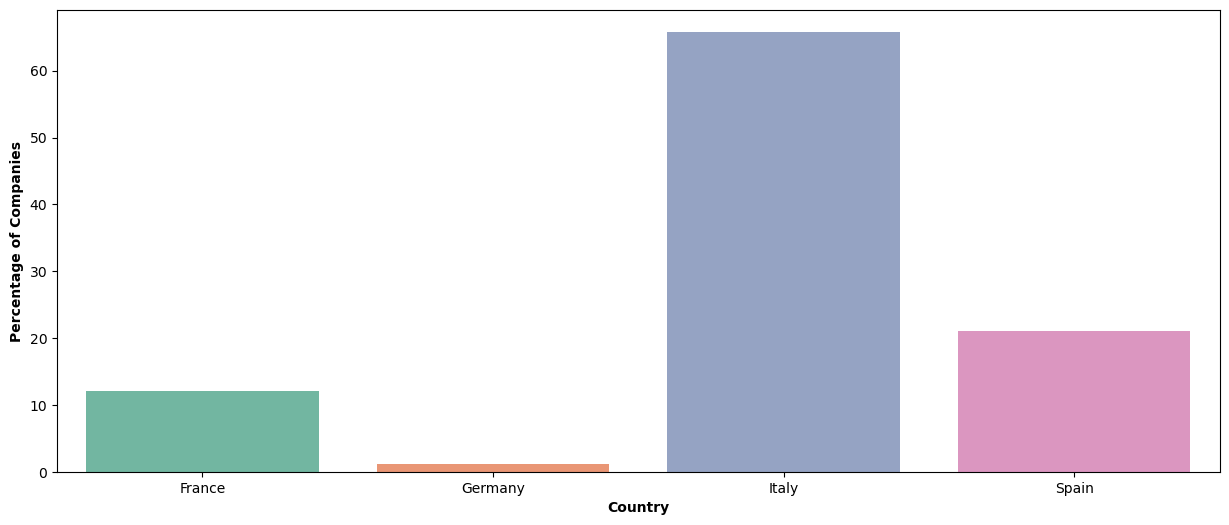

In [116]:
plt.figure(figsize=(15,6))
sns.barplot(grp , palette='Set2')
plt.ylabel('Percentage of Companies', fontweight='bold')
plt.xlabel('Country', fontweight='bold')
plt.show()

In [63]:
df.head()

,Company name,Turnover.2020,Turnover.2019,Turnover.2018,Turnover.2017,Turnover.2016,Turnover.2015,EBIT.2020,EBIT.2019,EBIT.2018,EBIT.2017,EBIT.2016,EBIT.2015,PLTax.2020,PLTax.2019,PLTax.2018,PLTax.2017,PLTax.2016,PLTax.2015,MScore.2020,MScore.2019,MScore.2018,MScore.2017,MScore.2016,MScore.2015,Region,Country,NACE code,Sector 1,Sector 2,Leverage.2020,Leverage.2019,Leverage.2018,Leverage.2017,Leverage.2016,Leverage.2015,ROE.2020,ROE.2019,ROE.2018,ROE.2017,ROE.2016,ROE.2015,TAsset.2020,TAsset.2019,TAsset.2018,TAsset.2017,TAsset.2016,TAsset.2015
0,LENDLEASE S.R.L.,29458,16716,9612,8097,7941.0,5600.0,-1556.0,-4540.0,623.0,-412.0,885.0,-1479.0,-1402.0,-4674.0,22.0,-360.0,368.0,-1140.0,CC,CC,CCC,C,BB,C,Milano,Italy,4200,Civil engineering,Capital Goods,14.33,9.90,56.77,64.15,21.46,48.07,-43.63,-180.22,8.24,-146.65,60.76,-471.72,49263,28268,15455,15992,13597.0,11659.0
1,PRICEWATERHOUSECOOPERS BUSINESS SERVICES SRL (...,16731,16403,16843,12241,9252.0,9515.0,1838.0,841.0,2738.0,-864.0,-2212.0,-3572.0,1600.0,700.0,2577.0,-900.0,-2187.0,-4591.0,A,BBB,BBB,CC,CCC,CCC,Milano,Italy,7022,Activities of head offices; management consult...,Commercial and professional services,1.86,2.45,2.92,5.65,2.90,1.29,27.60,14.30,61.42,-55.57,-127.29,-87.13,16550,16887,16468,10773,6697.0,8933.0
2,EVISO S.P.A.,48568,43039,34302,25791,19760.0,6941.0,1661.0,1464.0,976.0,495.0,162.0,224.0,1159.0,1047.0,779.0,267.0,63.0,123.0,BBB,BBB,BBB,BB,BB,BB,Cuneo,Italy,3514,"ELECTRICITY, GAS, STEAM AND AIR CONDITIONING S...",Utilities,3.59,3.49,4.44,7.69,12.54,9.39,39.38,48.89,57.52,42.73,20.34,44.62,13500,9620,7371,5432,4170.0,2862.0
3,CASA SERVICE MACHINE,47999,43484,43043,41682,51267.0,52584.0,416.0,255.0,-855.0,-23.0,426.0,969.0,236.0,107.0,-1002.0,-197.0,430.0,602.0,BB,B,CCC,B,BB,BB,Pas-de-Calais,France,4661,"Wholesale trade, except of motor vehicles and ...",Retailing,3.54,3.89,4.15,2.64,3.21,3.18,8.42,5.69,-17.24,0.71,2.89,6.45,24978,25032,25729,21632,25403.0,24941.0
4,PANFERTIL SPA,45948,47336,45626,48222,57074.0,62263.0,44.0,713.0,-672.0,-1091.0,97.0,987.0,3.0,48.0,-599.0,-821.0,-10.0,-1116.0,B,BB,CCC,CCC,B,B,Ravenna,Italy,4675,"Wholesale trade, except of motor vehicles and ...",Retailing,2.17,1.98,2.13,2.15,2.15,2.11,0.03,0.41,-5.17,-6.74,0.03,-8.19,36823,34659,36205,38423,41847.0,41323.0


In [64]:
df['Company name']=df['Company name'].str.strip() # removing unwanted spces from the  company name 

# Number of Companies

In [65]:
df['Company name'].nunique()

119412

# Year Wise Risk Analysis

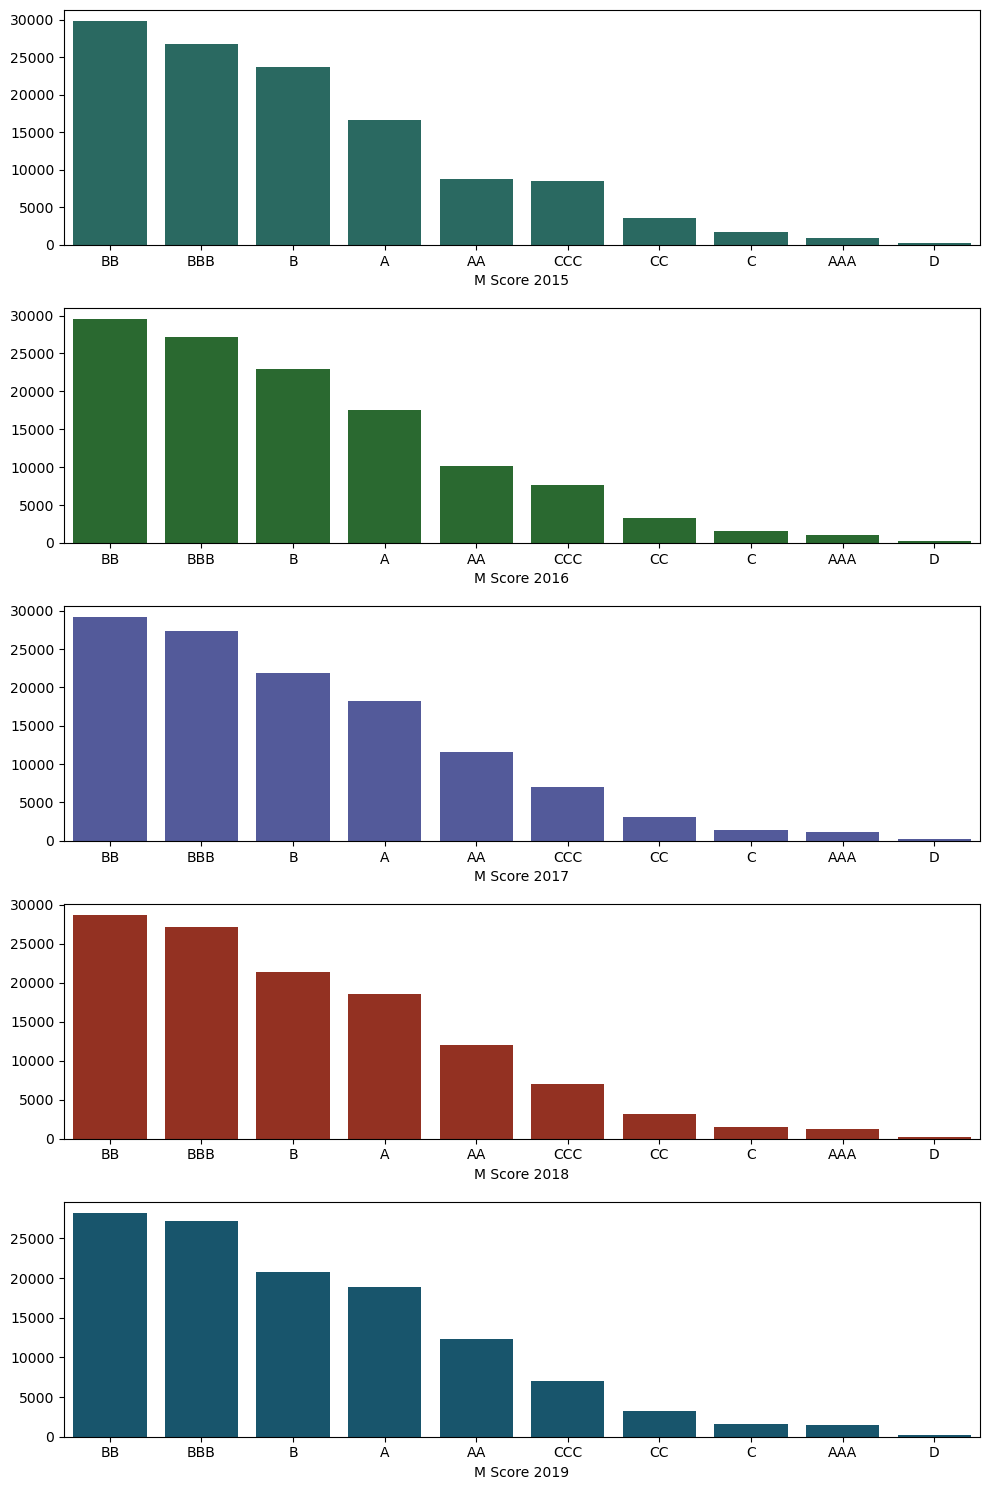

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,15))   # only ONE figure

plt.subplot(5,1,1)
sns.barplot(x=df['MScore.2015'].value_counts().index,
            y=df['MScore.2015'].value_counts().values,
            color='#207369')
plt.xlabel('M Score 2015')

plt.subplot(5,1,2)
sns.barplot(x=df['MScore.2016'].value_counts().index,
            y=df['MScore.2016'].value_counts().values,
            color='#207327')
plt.xlabel('M Score 2016')

plt.subplot(5,1,3)
sns.barplot(x=df['MScore.2017'].value_counts().index,
            y=df['MScore.2017'].value_counts().values,
            color='#4751a6')
plt.xlabel('M Score 2017')

plt.subplot(5,1,4)
sns.barplot(x=df['MScore.2018'].value_counts().index,
            y=df['MScore.2018'].value_counts().values,
            color='#a6230f')
plt.xlabel('M Score 2018')

plt.subplot(5,1,5)
sns.barplot(x=df['MScore.2019'].value_counts().index,
            y=df['MScore.2019'].value_counts().values,
            color='#0a5c7a')
plt.xlabel('M Score 2019')

plt.tight_layout()
plt.show()

# Details of Companies for General Sector 

**Percentage of companies for each general sector**

In [67]:
(df.groupby('Sector 2').size() / len(df) * 100).to_frame()

,0
Sector 2,
Automobiles and Components,2.735356
Capital Goods,14.461854
Commercial and professional services,8.953953
Consumer Durables and Apparel,3.950978
Consumer Services,2.948565
Diversified Financials,0.666072
Energy,0.075202
Food Beverage and Tobacco,5.879777
Food and Staples Retailing,7.297038


**Percentage of companies, in each country for each sector**

In [68]:
(df.groupby(['Country', 'Sector 2']).size() / (df.groupby(['Country']).size()) * 100).to_frame()

0
Country Sector 2                                       
France  Automobiles and Components             1.778317
        Capital Goods                         14.395195
        Commercial and professional services  13.433542
        Consumer Durables and Apparel          1.600781
        Consumer Services                      3.373180
...                                                 ...
Spain   Software and Services                  1.664607
        Technology Hardware and Equipment      0.428704
        Telecommunication Services             0.266492
        Transportation                         6.936505
        Utilities                              1.602812

[83 rows x 1 columns]

# Correlation Analysis
**Pearson Correlation**

In [69]:
corr_df=df.corr(numeric_only=True)

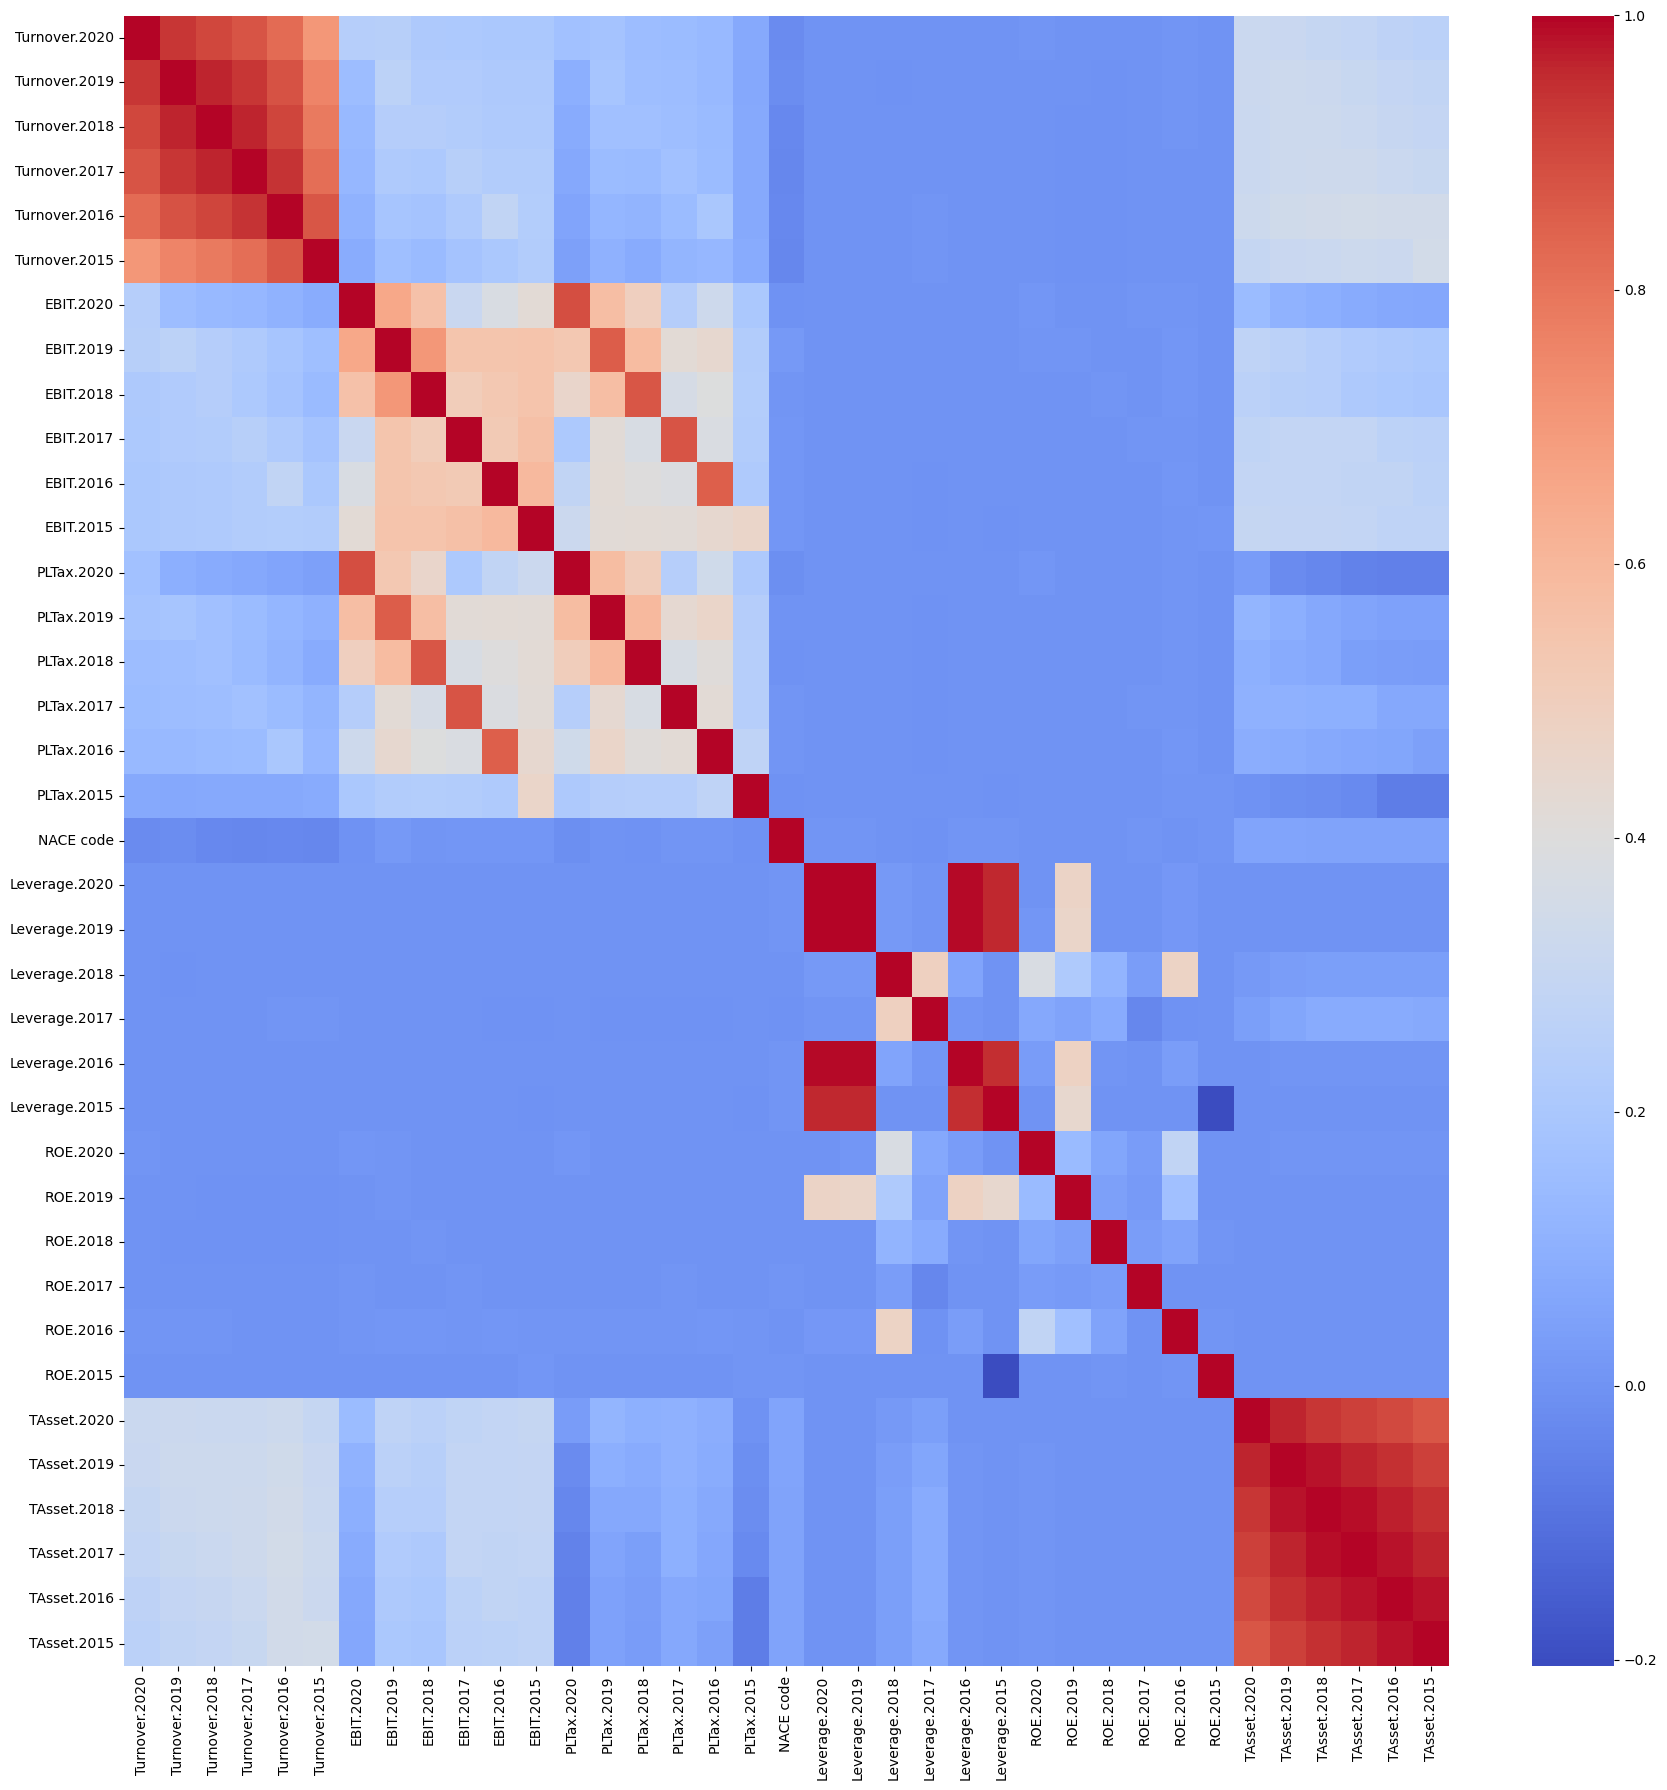

In [70]:
plt.figure(figsize=(18,18))
sns.heatmap(corr_df, cmap='coolwarm' )
plt.tight_layout()
plt.show()

Since our target variable is the MScore (in an year), basically we want to consider which are the variables that are more impacting the response varible (without taking into account possible spurious correlations with the features we are considering).
It is clear that the MScore in an year is positively correlated with previous years MScores (the correlation strength reduces with years). It basically means that if a company has an high credit risk level in an year it is highly possible that the same will happen in the following year (and also - but with less strength effect - also in the consequent ones).
Furthermore if we have the Turnover and the EBIT features in the same year, negative values of those two will cause an increase in the credit risk level.

**Percentage of companies for each country, for each credit risk level (select the year through the slider)**

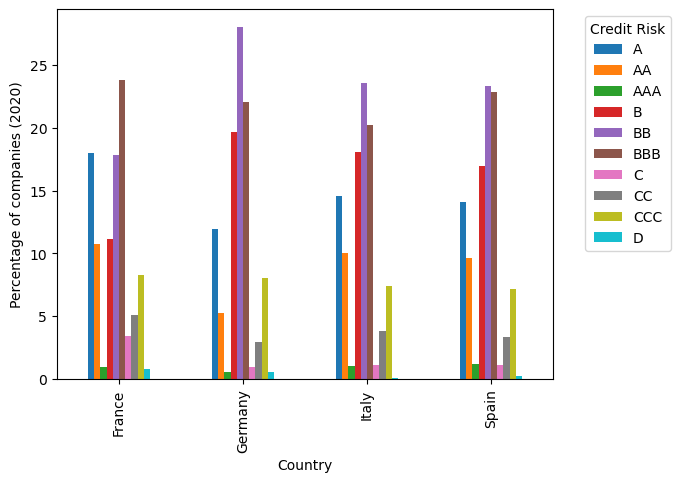

In [71]:
year = 2020
# automatically find the correct column for that year
col = [c for c in df.columns if str(year) in c and 'MScore' in c][0]
# calculate percentage
result = (
    df.groupby(['Country', col]).size()
    / df.groupby('Country').size()
    * 100
).unstack()

result.plot(kind='bar')

plt.xlabel('Country')
plt.ylabel(f'Percentage of companies ({year})')
plt.legend(title='Credit Risk', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

ACCORDING TO THE CATEGORY OF RISK ASSIGNING LOW OR HIGH

In [92]:
def MScore_to_int(x):
    if x in ['A', 'AA','B','BB','AAA','BBB']:
        return 0
    elif x in ['D','CCC','C','CC']:
        return 1
    else:
        return None

**CONVERTING TO MScore to integer**

In [93]:
for col in [c for c in df.columns if c.startswith('MScore.')]:
    df[str(col)+'.int'] = df[str(col)].apply(lambda x: MScore_to_int(x))

**companies have more an high or low credit risk (on average, on different years)?**

In [94]:
low, high = [], [] 
for year in range(2015, 2021):
    low.append(df['MScore.'+str(year)+'.int'].value_counts()[0])
    high.append(df['MScore.'+str(year)+'.int'].value_counts()[1])
print('Average number of low level credit risk companies:', int(np.mean(low)))
print('Average number of high level credit risk companies:', int(np.mean(high)))

Average number of low level credit risk companies: 107824
Average number of high level credit risk companies: 13184


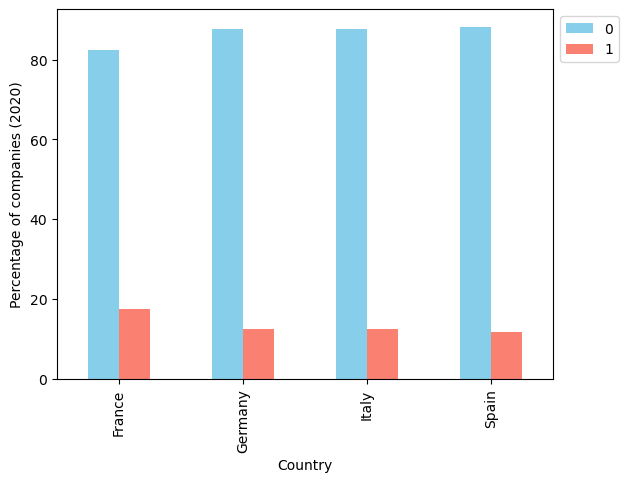

In [114]:
year = 2020  
result = (
    df.groupby(['Country', f'MScore.{year}.int']).size()
    / df.groupby('Country').size()
    * 100
).unstack()

# plot
result.plot(kind='bar', color=['skyblue', 'salmon'])
plt.xlabel('Country')
plt.ylabel(f'Percentage of companies ({year})')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

**Percentage of companies with low or high credit risk, for each sector (in an year)**

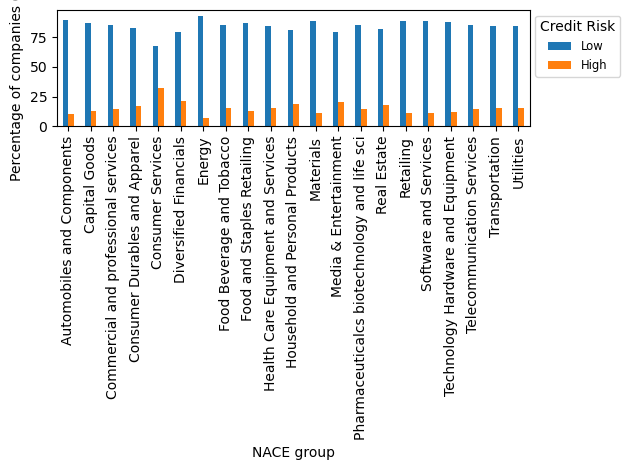

In [115]:
year = 2020  

(df.groupby([f'MScore.{year}.int', 'Sector 2']).size()
    / df.groupby(['Sector 2']).size()
    * 100
).unstack(f'MScore.{year}.int').plot.bar()

plt.xlabel('NACE group')
plt.ylabel(f'Percentage of companies ({year})')
plt.legend(['Low', 'High'], title='Credit Risk',
           fontsize='small',loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Save the data Machine Learning models

In [123]:
df.to_csv(r'C:\Users\lenovo\Downloads\Machine_learning_ready.csv', index=False)